In [25]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

df= pd.read_csv('../data collections/WineQT (1).csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [26]:
X= df.drop(['quality', 'Id'], axis=1)
y= df.quality


X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

print(y_train.value_counts())

quality
5    386
6    370
7    114
4     26
8     13
3      5
Name: count, dtype: int64


In [27]:
smote= SMOTE(random_state=0, k_neighbors=4)

X_train_smote, y_train_smote= smote.fit_resample(X_train, y_train) #type: ignore

print("\nEfter SMOTE:")
print(y_train_smote.value_counts())


Efter SMOTE:
quality
5    386
6    386
7    386
8    386
4    386
3    386
Name: count, dtype: int64


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=0,
                            criterion='gini',
                            max_depth=10,
                            min_samples_leaf=15,
                            min_samples_split=8
                            )
dt.fit(X_train_smote, y_train_smote)

pred = dt.predict(X_test)

print("\nTrain score:", dt.score(X_train_smote, y_train_smote)) #type:ignore
print("Test score:", dt.score(X_test, y_test))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Train score: 0.7845423143350605
Test score: 0.4847161572052402
[[ 0  1  0  0  0  0]
 [ 0  3  2  2  0  0]
 [11 11 52 18  5  0]
 [ 2  8 19 44 12  7]
 [ 0  0  4  9 12  4]
 [ 0  0  0  0  3  0]]
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.13      0.43      0.20         7
           5       0.68      0.54      0.60        97
           6       0.60      0.48      0.53        92
           7       0.38      0.41      0.39        29
           8       0.00      0.00      0.00         3

    accuracy                           0.48       229
   macro avg       0.30      0.31      0.29       229
weighted avg       0.58      0.48      0.52       229



In [29]:
for depth in [3, 4, 5, 6, 7, 8]:
    for leaf in [1, 2, 4, 6, 10]:
        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=leaf,
            min_samples_split=10,
            random_state=0
        )

        model.fit(X_train, y_train)

        train_score = model.score(X_train, y_train)
        test_score = model.score(X_test, y_test)

        print(f"depth={depth}, leaf={leaf}, train={train_score:.3f}, test={test_score:.3f}")

    #depth=8, leaf=4, train=0.755, test=0.598

depth=3, leaf=1, train=0.594, test=0.498
depth=3, leaf=2, train=0.594, test=0.498
depth=3, leaf=4, train=0.592, test=0.502
depth=3, leaf=6, train=0.592, test=0.502
depth=3, leaf=10, train=0.593, test=0.502
depth=4, leaf=1, train=0.638, test=0.524
depth=4, leaf=2, train=0.637, test=0.524
depth=4, leaf=4, train=0.639, test=0.528
depth=4, leaf=6, train=0.635, test=0.533
depth=4, leaf=10, train=0.631, test=0.546
depth=5, leaf=1, train=0.676, test=0.537
depth=5, leaf=2, train=0.674, test=0.533
depth=5, leaf=4, train=0.673, test=0.541
depth=5, leaf=6, train=0.668, test=0.537
depth=5, leaf=10, train=0.668, test=0.537
depth=6, leaf=1, train=0.691, test=0.520
depth=6, leaf=2, train=0.689, test=0.515
depth=6, leaf=4, train=0.693, test=0.546
depth=6, leaf=6, train=0.685, test=0.546
depth=6, leaf=10, train=0.684, test=0.537
depth=7, leaf=1, train=0.729, test=0.515
depth=7, leaf=2, train=0.723, test=0.502
depth=7, leaf=4, train=0.726, test=0.550
depth=7, leaf=6, train=0.713, test=0.563
depth=7, lea

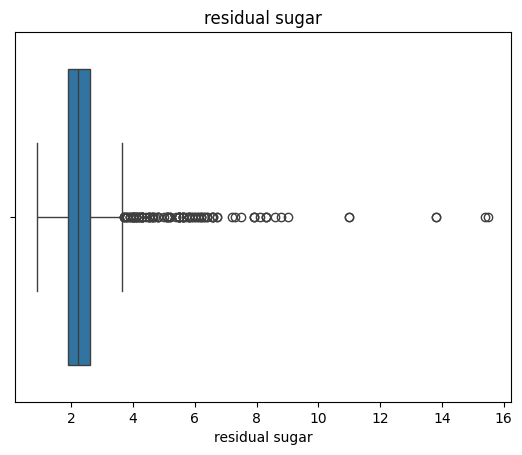

residual sugar
count    1143.000000
mean        2.532152
std         1.355917
min         0.900000
25%         1.900000
50%         2.200000
75%         2.600000
max        15.500000
Name: residual sugar, dtype: float64
339     15.5
1022    15.4
1051    13.8
1053    13.8
231     11.0
230     11.0
644      9.0
648      8.8
460      8.6
760      8.3
Name: residual sugar, dtype: float64



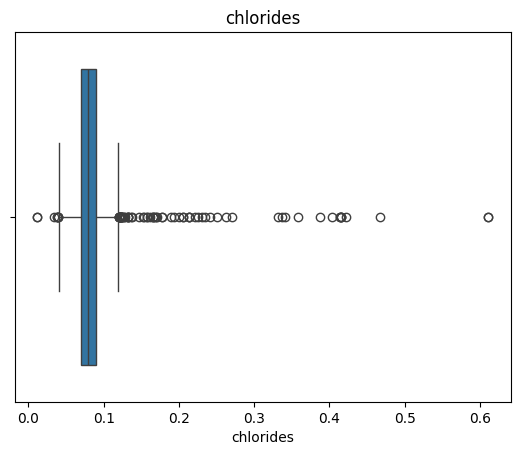

chlorides
count    1143.000000
mean        0.086933
std         0.047267
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64
182    0.611
103    0.610
75     0.467
490    0.422
538    0.415
973    0.415
975    0.415
934    0.414
738    0.414
890    0.403
Name: chlorides, dtype: float64



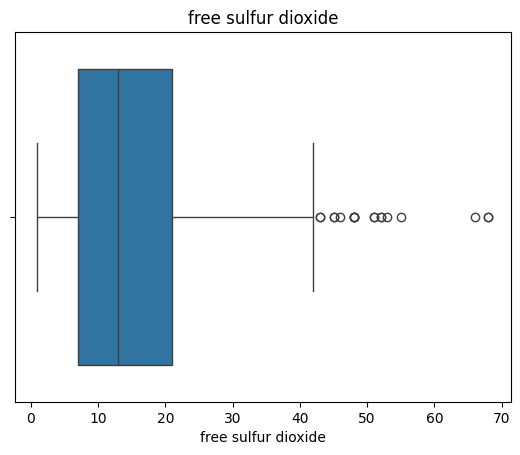

free sulfur dioxide
count    1143.000000
mean       15.615486
std        10.250486
min         1.000000
25%         7.000000
50%        13.000000
75%        21.000000
max        68.000000
Name: free sulfur dioxide, dtype: float64
278     68.0
275     68.0
1111    66.0
1022    55.0
654     53.0
655     52.0
965     52.0
919     51.0
690     51.0
871     48.0
Name: free sulfur dioxide, dtype: float64



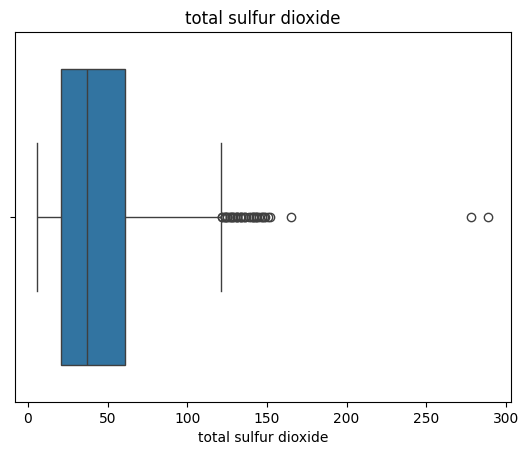

total sulfur dioxide
count    1143.000000
mean       45.914698
std        32.782130
min         6.000000
25%        21.000000
50%        37.000000
75%        61.000000
max       289.000000
Name: total sulfur dioxide, dtype: float64
761     289.0
760     278.0
249     165.0
485     152.0
366     151.0
421     149.0
460     148.0
1066    147.0
452     147.0
453     145.0
Name: total sulfur dioxide, dtype: float64



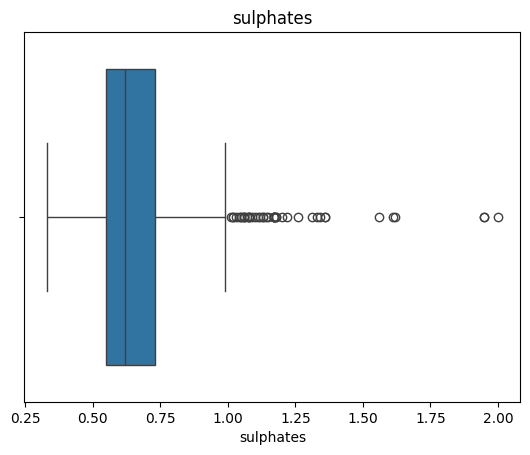

sulphates
count    1143.000000
mean        0.657708
std         0.170399
min         0.330000
25%         0.550000
50%         0.620000
75%         0.730000
max         2.000000
Name: sulphates, dtype: float64
103    2.00
64     1.95
59     1.95
514    1.62
161    1.61
11     1.56
454    1.36
240    1.36
738    1.34
934    1.33
Name: sulphates, dtype: float64



In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "sulphates"]

for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

    print(col)
    print(df[col].describe())
    print(df[col].sort_values(ascending=False).head(10))
    print()

In [31]:
import numpy as np

log_cols = ["residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "sulphates"]

X_train_log = X_train.copy()
X_val_log = X_test.copy()

for col in log_cols:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_val_log[col] = np.log1p(X_val_log[col])

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

def evaluate_tree(X_train_used, X_val_used, y_train, y_val, max_depth=9, min_samples_leaf=1, min_samples_split=2):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        random_state=0
    )

    model.fit(X_train_used, y_train)

    train_score = model.score(X_train_used, y_train)
    val_score = model.score(X_val_used, y_val)

    print("Train score:", train_score)
    print("Val score:", val_score)

    return model

In [33]:
print("Original")
model_original = evaluate_tree(X_train, X_test, y_train, y_test)


print("\nLog-transformed")
model_log = evaluate_tree(X_train_log, X_val_log, y_train, y_test)

Original
Train score: 0.8260393873085339
Val score: 0.5895196506550219

Log-transformed
Train score: 0.8260393873085339
Val score: 0.5895196506550219
